# Loss Functions & Gradient Descent — Hands-on Tutorial

In this notebook we'll build intuition for:
1. **L1 vs L2 loss** — manually fitting a line by dragging sliders
2. **Local minima** — why starting point matters (1D)
3. **Gradient descent** — watching an optimizer navigate a bumpy 2D loss surface
4. **Robust fitting** — L1 vs L2 loss under outliers with `scipy.minimize`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from scipy.optimize import minimize

---
## Part 1: Loss by Hand

We generate noisy data from the line $y = 2x + 1$ and let you fit it manually.

Use the sliders to adjust $m$ (slope) and $b$ (intercept).
The plot shows your current line, the residuals (vertical bars from each point to the line),
and both loss values:

- **L1 loss (MAE):** $\frac{1}{n}\sum_i |y_i - (mx_i + b)|$
- **L2 loss (MSE):** $\frac{1}{n}\sum_i (y_i - (mx_i + b))^2$

In [11]:
# Generate noisy data from y = 2x + 1
np.random.seed(42)
n_pts = 15

# x_data: 15 evenly spaced input values from 0 to 5
# y_data: the true line (2x + 1) plus Gaussian noise (σ=1.5)
# These arrays are used throughout Parts 1 and 2 — they're our "dataset".
x_data = np.linspace(0, 5, n_pts)
y_data = 2 * x_data + 1 + np.random.normal(scale=1.5, size=n_pts)


def plot_fit(m, b):
    """Plot data, fitted line, residual bars, and both loss values."""
    y_pred = m * x_data + b
    residuals = y_data - y_pred

    l1_loss = np.mean(np.abs(residuals))
    l2_loss = np.mean(residuals ** 2)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(x_data, y_data, color='black', s=50, zorder=3, label='Data')

    # Residual bars
    for xi, yi, yp in zip(x_data, y_data, y_pred):
        ax.plot([xi, xi], [yi, yp], color='tab:red', linewidth=1.5, alpha=0.6)

    # Fitted line
    x_line = np.linspace(-0.5, 5.5, 100)
    ax.plot(x_line, m * x_line + b, color='tab:blue', linewidth=2,
            label=f'y = {m:.2f}x + {b:.2f}')

    ax.set_xlim(-0.5, 5.5)
    ax.set_ylim(-4, 16)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'L1 loss = {l1_loss:.3f}   |   L2 loss = {l2_loss:.3f}')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


interact(
    plot_fit,
    m=FloatSlider(value=0.5, min=-1.0, max=5.0, step=0.05, description='slope m'),
    b=FloatSlider(value=0.0, min=-5.0, max=10.0, step=0.1, description='intercept b'),
);

interactive(children=(FloatSlider(value=0.5, description='slope m', max=5.0, min=-1.0, step=0.05), FloatSlider…

### Think about it

- Can you get the L2 loss below 2.0?  Below 1.5?
- Do the optimal slider positions differ for L1 vs L2?  (Hint: try values near $m=2$, $b=1$.)
- Why do the red residual bars grow faster for L2 than for L1 when you're far from the best fit?

### Finding the optimal fit with `scipy.optimize.minimize`

Now let's find the *actual* minimum-loss line using an optimizer.

`scipy.optimize.minimize` expects a **scalar function** — one that takes a single
array of parameters and returns a single number (the loss). It then searches for
the parameter values that make that number as small as possible.

Your job: write the L2 and L1 loss functions below. Each one should:
1. Unpack the parameter array into slope and intercept
2. Compute the predicted $y$ values
3. Compute and return the mean loss

L2-optimal line:  y = 1.439x + 2.417   (MSE = 1.3275)
L1-optimal line:  y = 1.597x + 1.745   (MAE = 0.9534)


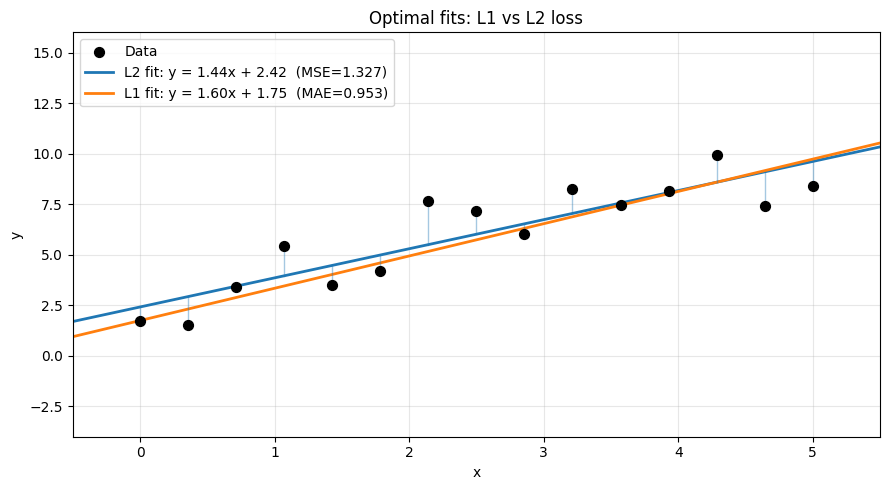

In [12]:
# scipy.optimize.minimize requires the function signature f(params) -> scalar,
# where params is a 1-D array of all the values the optimizer is free to adjust.
# For a line y = m*x + b, params = [m, b].

def line_l2_loss(params):
    """Mean Squared Error: average of squared residuals."""
    m, b = params  # unpack the parameter array into named variables

    y_pred = m * x_data + b
    residuals = y_data - y_pred
    return np.mean(residuals ** 2)


def line_l1_loss(params):
    """Mean Absolute Error: average of absolute residuals."""
    m, b = params

    y_pred = m * x_data + b
    residuals = y_data - y_pred
    return np.mean(np.abs(residuals))


# Run the optimizer: start from m=0, b=0 and let it search
p0 = [0.0, 0.0]
opt_l2 = minimize(line_l2_loss, p0, method='Nelder-Mead')
opt_l1 = minimize(line_l1_loss, p0, method='Nelder-Mead')

m_l2, b_l2 = opt_l2.x
m_l1, b_l1 = opt_l1.x

print(f"L2-optimal line:  y = {m_l2:.3f}x + {b_l2:.3f}   (MSE = {opt_l2.fun:.4f})")
print(f"L1-optimal line:  y = {m_l1:.3f}x + {b_l1:.3f}   (MAE = {opt_l1.fun:.4f})")

# Plot both optimal fits
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x_data, y_data, color='black', s=50, zorder=3, label='Data')

x_line = np.linspace(-0.5, 5.5, 100)
ax.plot(x_line, m_l2 * x_line + b_l2, color='tab:blue', linewidth=2,
        label=f'L2 fit: y = {m_l2:.2f}x + {b_l2:.2f}  (MSE={opt_l2.fun:.3f})')
ax.plot(x_line, m_l1 * x_line + b_l1, color='tab:orange', linewidth=2,
        label=f'L1 fit: y = {m_l1:.2f}x + {b_l1:.2f}  (MAE={opt_l1.fun:.3f})')

# Residual bars for L2 fit
for xi, yi in zip(x_data, y_data):
    yp = m_l2 * xi + b_l2
    ax.plot([xi, xi], [yi, yp], color='tab:blue', linewidth=1, alpha=0.4)

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-4, 16)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Optimal fits: L1 vs L2 loss')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 2: The Local Minima Trap (1D)

Before we look at gradient descent on a real loss surface, let's build intuition
in one dimension.

Consider a non-convex loss function with two wells:

$$\mathcal{L}(w) = w^4 - 4w^2 + w$$

Use the slider to pick a starting point $w_0$ and watch where GD lands.

In [13]:
def loss_fn(w):
    return w**4 - 4 * w**2 + w

def grad_fn(w):
    return 4 * w**3 - 8 * w + 1


def plot_local_minima(w0):
    lr = 0.01
    n_steps = 300
    w = w0
    history = [w]

    for _ in range(n_steps):
        w = w - lr * grad_fn(w)
        history.append(w)

    history = np.array(history)
    losses = loss_fn(history)

    w_plot = np.linspace(-2.5, 2.5, 500)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(w_plot, loss_fn(w_plot), 'k-', linewidth=2, label='$\\mathcal{L}(w)$')
    ax.plot(history, losses, 'o-', color='tab:red', markersize=3,
            linewidth=1, alpha=0.7, label='GD trajectory')
    ax.plot(history[0], losses[0], 's', color='yellow', markersize=12,
            zorder=5, label=f'Start ($w_0$={w0:.1f})')
    ax.plot(history[-1], losses[-1], '*', color='red', markersize=16,
            zorder=5, label=f'End ($w$={history[-1]:.3f})')

    ax.set_xlabel('w')
    ax.set_ylabel('$\\mathcal{L}(w)$')
    ax.set_title(f'Final loss = {losses[-1]:.4f}')
    ax.set_ylim(-6, 10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


interact(
    plot_local_minima,
    w0=FloatSlider(value=2.0, min=-2.5, max=2.5, step=0.1,
                   description='w₀ (start)'),
);

interactive(children=(FloatSlider(value=2.0, description='w₀ (start)', max=2.5, min=-2.5), Output()), _dom_cla…

### Think about it

- Starting at $w_0 = 2.0$, which minimum does GD find? Is it the global minimum?
- Starting at $w_0 = -2.0$, where does it go?
- Can you find a starting point that lands in the *other* well?
- What does this tell you about why initialization matters in deep learning?

---
## Part 3: Gradient Descent on a Bumpy Surface (2D)

Now the same idea, but in two dimensions with a real model: $y = a \sin(b\,x)$.

The loss surface here is **non-convex** — it has ridges, valleys, and multiple
local minima (due to the periodicity of $\sin$). You can control:
- **Learning rate** $\eta$ — how big each step is
- **Start position** $(a_0, b_0)$ — where the optimizer begins

The gradients of MSE with respect to $a$ and $b$ are:

$$\frac{\partial \mathcal{L}}{\partial a} = -\frac{2}{n}\sum_i \sin(b\,x_i)\,(y_i - a\sin(b\,x_i))$$

$$\frac{\partial \mathcal{L}}{\partial b} = -\frac{2}{n}\sum_i a\,x_i\cos(b\,x_i)\,(y_i - a\sin(b\,x_i))$$

In [5]:
from ipywidgets import FloatText

# Generate data from y = 3*sin(2*x) + noise
np.random.seed(0)
x2 = np.linspace(0.1, 2 * np.pi, 30)
y2 = 3.0 * np.sin(2.0 * x2) + np.random.normal(scale=0.5, size=len(x2))


def run_gd(lr, a0, b0, n_steps=300):
    """Run gradient descent on MSE for y = a*sin(b*x). Returns parameter history."""
    a, b = a0, b0
    history = [(a, b)]

    for _ in range(n_steps):
        pred = a * np.sin(b * x2)
        residuals = y2 - pred
        grad_a = -2 * np.mean(np.sin(b * x2) * residuals)
        grad_b = -2 * np.mean(a * x2 * np.cos(b * x2) * residuals)
        a -= lr * grad_a
        b -= lr * grad_b
        history.append((a, b))

    return np.array(history)


# Precompute loss surface on a grid
a_grid = np.linspace(-1, 5, 300)
b_grid = np.linspace(-1, 5, 300)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)
L = np.zeros_like(A_grid)
for i in range(len(x2)):
    L += (y2[i] - A_grid * np.sin(B_grid * x2[i])) ** 2
L /= len(x2)


def plot_gd(lr, a0, b0):
    history = run_gd(lr, a0, b0)
    losses = [np.mean((y2 - h[0] * np.sin(h[1] * x2)) ** 2) for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: contour map with optimizer path
    ax1.contourf(A_grid, B_grid, L, levels=40, cmap='viridis', alpha=0.8)
    ax1.contour(A_grid, B_grid, L, levels=40, colors='k', linewidths=0.3, alpha=0.4)
    ax1.plot(history[:, 0], history[:, 1], 'o-', color='white',
             markersize=3, linewidth=1.2, label='GD path')
    ax1.plot(history[0, 0], history[0, 1], 's', color='yellow',
             markersize=10, zorder=5, label='Start')
    ax1.plot(history[-1, 0], history[-1, 1], '*', color='red',
             markersize=14, zorder=5, label='End')
    ax1.set_xlabel('a (amplitude)')
    ax1.set_ylabel('b (frequency)')
    ax1.set_title(f'L2 Loss Surface  |  η = {lr}')
    ax1.legend(loc='upper right', fontsize=9)

    # Right: loss vs iteration
    ax2.plot(losses, color='tab:blue', linewidth=1.5)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('MSE Loss')
    ax2.set_title(f'Final loss = {losses[-1]:.4f}')
    ax2.set_ylim(0, max(losses[0] * 1.1, losses[-1] * 2))
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


interact(
    plot_gd,
    lr=FloatSlider(value=0.01, min=0.001, max=0.1, step=0.001,
                   description='η (lr)', readout_format='.3f'),
    a0=FloatText(value=1.0, description='a₀ (start)', step=0.5),
    b0=FloatText(value=0.5, description='b₀ (start)', step=0.5),
);

interactive(children=(FloatSlider(value=0.01, description='η (lr)', max=0.1, min=0.001, readout_format='.3f', …

### Think about it

- With the default start $(1.0, 0.5)$ and $\eta = 0.01$, where does GD converge? Is it the global minimum?
- Try starting at $(3.0, 2.0)$ — that's near the true parameters. Does it converge faster?
- Try starting at $(1.0, 4.0)$ — a different valley. Where does it end up?
- At high $\eta$, does the optimizer escape local minima or just diverge?
- Why are there multiple valleys? (Hint: think about what $\sin(b\,x)$ looks like for different $b$.)

---
## Part 4: Fit a Sine Wave with `scipy.minimize`

We generate noisy data from $y = A\sin(\omega t + \phi)$ with known true parameters,
then fit the model using L2 and L1 loss.

**Your task:** fill in the model and loss functions below.

In [6]:
# True parameters
A_true, omega_true, phi_true = 3.0, 2.0, 0.5

np.random.seed(7)
t = np.linspace(0, 2 * np.pi, 60)
y_clean = A_true * np.sin(omega_true * t + phi_true)
y_noisy = y_clean + np.random.normal(scale=0.4, size=len(t))

# Uncomment the next two lines to add outliers, then re-run the fits below
# outlier_idx = [5, 18, 33, 47]
# y_noisy[outlier_idx] += np.array([8.0, -9.0, 7.0, -8.0])

In [7]:
def sine_model(params, t):
    """Sine wave model: y = A * sin(omega * t + phi)"""
    A, omega, phi = params
    return A * np.sin(omega * t + phi)


def l2_loss(params, t, y):
    """Mean squared error between model and data."""
    y_pred = sine_model(params, t)
    return np.mean((y - y_pred) ** 2)


def l1_loss(params, t, y):
    """Mean absolute error between model and data."""
    y_pred = sine_model(params, t)
    return np.mean(np.abs(y - y_pred))

In [8]:
# Fit with L2 loss
p0 = [2.0, 1.5, 0.0]  # initial guess
result_l2 = minimize(l2_loss, p0, args=(t, y_noisy), method='Nelder-Mead')
print(f"L2 fit:  A={result_l2.x[0]:.3f}, ω={result_l2.x[1]:.3f}, φ={result_l2.x[2]:.3f}")
print(f"  True:  A={A_true}, ω={omega_true}, φ={phi_true}")

L2 fit:  A=2.941, ω=1.994, φ=0.518
  True:  A=3.0, ω=2.0, φ=0.5


In [9]:
# Fit with L1 loss
result_l1 = minimize(l1_loss, p0, args=(t, y_noisy), method='Nelder-Mead')
print(f"L1 fit:  A={result_l1.x[0]:.3f}, ω={result_l1.x[1]:.3f}, φ={result_l1.x[2]:.3f}")
print(f"  True:  A={A_true}, ω={omega_true}, φ={phi_true}")

L1 fit:  A=2.895, ω=2.094, φ=-0.001
  True:  A=3.0, ω=2.0, φ=0.5


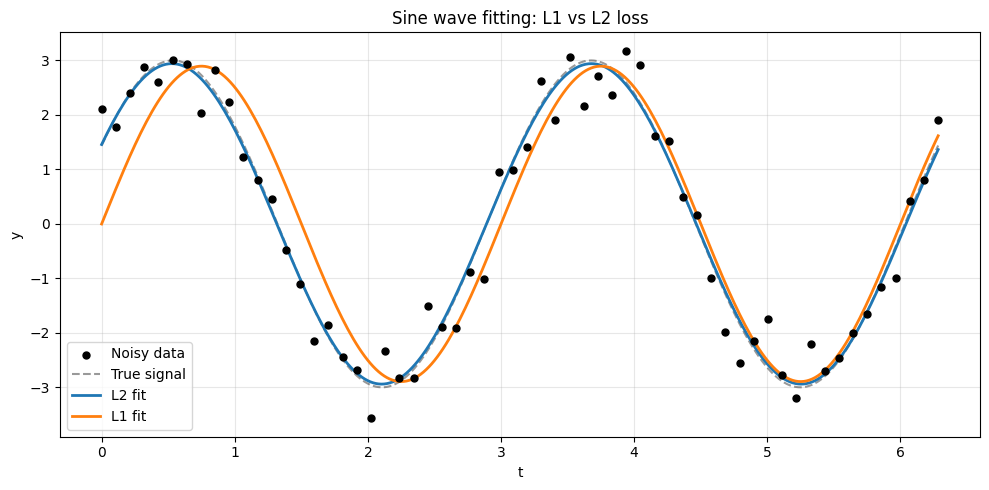

In [10]:
# Plot: data, true signal, and both fits
t_fine = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(t, y_noisy, color='black', s=25, zorder=3, label='Noisy data')
ax.plot(t_fine, A_true * np.sin(omega_true * t_fine + phi_true),
        'k--', linewidth=1.5, alpha=0.4, label='True signal')
ax.plot(t_fine, sine_model(result_l2.x, t_fine),
        color='tab:blue', linewidth=2, label='L2 fit')
ax.plot(t_fine, sine_model(result_l1.x, t_fine),
        color='tab:orange', linewidth=2, label='L1 fit')

ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title('Sine wave fitting: L1 vs L2 loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Think about it

- Without outliers, do L1 and L2 give similar fits?
- Now go back and **uncomment** the outlier lines in the data cell, re-run all cells.
  How does each fit change?
- Which loss is more *robust* to outliers? Why does L2 get pulled toward them more?
- Connection to the lecture: L2 squares the residuals, so large errors (outliers) get
  amplified quadratically. L1 treats them linearly — outliers have less leverage.